We model the following ODE driven by the El Centro Earthquake:
$$
\ddot u(t) + 2\xi\omega_n\,\dot u(t) + \omega_n^{2}u(t)
        = -9.81\,a(t),
\qquad
u(0)=\dot u(0)=0,
$$
where $a(t)$ is the normalized ground-acceleration record, $\xi$ is the damping ratio, and $\omega_n$ is the natural frequency.


In the experiment, we take:
- $\xi = 0.02$
- $T_n = 5\,\mathrm{s}$
- $\omega_n = 2\pi/T_n$
 

## Imports

In [9]:
import os, sys, importlib

REPO = "/content/BSK_ODE"

print("Python executable:", sys.executable)
print("Repo exists:", os.path.exists(REPO))
print("Package exists:", os.path.exists(f"{REPO}/bsk_ode"))
print("Init exists:", os.path.exists(f"{REPO}/bsk_ode/__init__.py"))
print("Before:", [p for p in sys.path if "BSK_ODE" in p])

sys.path.insert(0, REPO)
importlib.invalidate_caches()

print("After:", [p for p in sys.path if "BSK_ODE" in p])

import bsk_ode
print("bsk_ode loaded from:", bsk_ode.__file__)

from bsk_ode import elcentro
print("elcentro loaded from:", elcentro.__file__)

Python executable: /usr/bin/python3
Repo exists: True
Package exists: True
Init exists: True
Before: ['/content/BSK_ODE', '/content/BSK_ODE']
After: ['/content/BSK_ODE', '/content/BSK_ODE', '/content/BSK_ODE']
bsk_ode loaded from: /content/BSK_ODE/bsk_ode/__init__.py
elcentro loaded from: /content/BSK_ODE/bsk_ode/elcentro.py


In [10]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.elcentro import *
print("Using device:", device, "torch", torch.__version__)

Already up to date.
Using device: cuda torch 2.11.0+cu128


## Problem and Model Parameters

In [11]:
# Problem Setup
xi = .02
Tn = 5
omega = (2 * math.pi) / Tn

m = 1
c = 2 * xi * omega * m
k = omega ** 2
a = -9.81



signature_level = 12
reg_lambda = 1e-5
use_normalization = True



## Import Forcing and data

In [12]:
import os
os.chdir("/content/BSK_ODE")    # <- adjust if your clone path is different
F_t = pd.read_csv("Data/EQDATA.csv")        # from repo root
t_vals = torch.tensor(F_t["t"].values, dtype=torch.float64)
F_vals = a * torch.tensor(F_t["F"].values, dtype=torch.float64)
t_start = 0
t_end = 31.18
N = len(F_t)
dt = t_vals[1] - t_vals[0]
F_star = trapezoidal_cols(trapezoidal_cols(F_vals, dt), dt)


# Check Conditioning

In [ ]:
diagnose_conditioning(t_vals, F_vals, m,c,k, 0, 0, signature_level, reg_lambda)


--- non-normalized ---
X_sig      | shape=(1560, 126) | rank= 126 | rcond=5.393e-11 | cond=1.854e+10
Ksig       | shape=(1560, 1560) | rank=  42 | rcond=0.000e+00 | cond=inf


KeyboardInterrupt: 

## Run calibration

In [13]:
t_ref, U_ref = solve_linear_ivp(
    x_grid = t_vals,
    forcing_torch = F_vals,
    a = t_start, 
    b = t_end,
    ya = 0, 
    ypa = 0,
    k1 = m, 
    k2 = c,
    k3 = k
    )

U_hat, F_hat, _ = solve_signature_kernel_calibration(
    x=t_vals,        # time grid
    f=F_vals,        # raw forcing (a_g * acceleration)
    k1=m,            # mass
    k2=c,            # damping
    k3=k,            # stiffness
    ua=0.0,          # u(0)
    upa=0.0,         # u'(0)
    depth=signature_level,
    normalize=use_normalization,
    reg = reg_lambda
)



GPU SVD | device=cuda:0 | rank=621/1560 | rcond=2.220e-16 | cutoff=3.541e-07


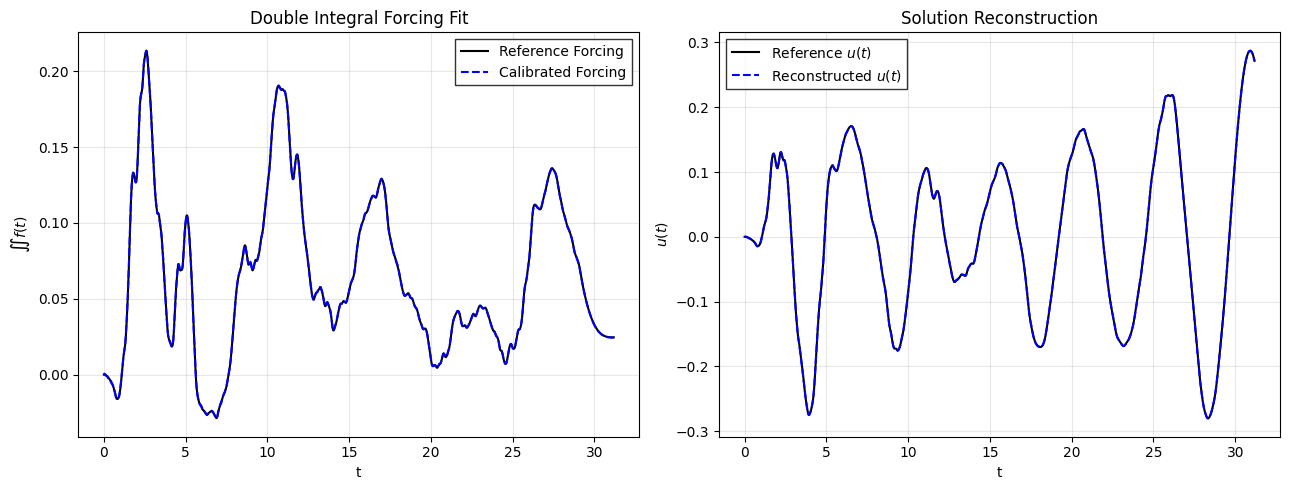


Model Error Summary
Quantity                   Absolute MSE       Relative MSE     Relative MSE (%)
--------------------------------------------------------------------------------
Forcing F*                 4.620266e-08       6.663556e-06              0.0007%
Solution u(t)              5.424332e-08       3.167049e-06              0.0003%


In [14]:
plot_calibration(t_vals, F_star, F_hat, U_ref, U_hat)
print_errors_calibration(F_hat,F_star,U_hat,U_ref)

# Testing Parameters

In [ ]:
TRAIN_FRAC = 0.5  # fraction of grid points used for training
holder_value = .2
reg_lambda = 1e-5

sig_depth_predict = 3
retrain_iters_predict = 5

sig_depth_rolling = 5
retrain_iters_rolling = 5

use_normalization = False



#Train / Test Split
N_train = int(N * TRAIN_FRAC)
N_test  = N - N_train

# Training slice: first N_train points (contiguous, causal split)
t_train  = t_vals[:N_train]
t_test   = t_vals[N_train:]
f_train  = F_vals[:N_train]     # raw forcing, not F_star
f_test   = F_vals[N_train:]


print(f"Total grid points : {N}")
print(f"Train points      : {N_train}  (x in [{float(t_train[0]):.3f}, {float(t_train[-1]):.3f}])")
print(f"Test  points      : {N_test}   (x in [{float(t_test[0]):.3f},  {float(t_test[-1]):.3f}])")

Total grid points : 1560
Train points      : 780  (x in [0.000, 15.580])
Test  points      : 780   (x in [15.600,  31.180])


## Prediction and retrain

In [ ]:
import time

# ---- prediction with periodic retraining ----
if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full, f_pred_full = solve_signature_kernel_predict_retrain(
    t_train=t_train,
    t_test=t_test,
    f_train=f_train,
    f_test=f_test,
    k1=m,
    k2=c,
    k3=k,
    ua=0.0,
    upa=0.0,
    depth=sig_depth_predict,
    normalize=use_normalization,
    reg=reg_lambda,
    retrain_every=retrain_iters_predict
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for direct prediction and retrain method: {elapsed:.3f} seconds")

# ---- prediction with periodic retraining and t lift----
if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_tlift, f_pred_full_tlift = solve_signature_kernel_predict_retrain(
    t_train=t_train,
    t_test=t_test,
    f_train=f_train,
    f_test=f_test,
    k1=m,
    k2=c,
    k3=k,
    ua=0.0,
    upa=0.0,
    depth=sig_depth_predict,
    normalize=use_normalization,
    reg=reg_lambda,
    retrain_every=retrain_iters_predict,
    use_tlift=True,
    holder_value=holder_value
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for direct prediction and retrain method, tlift: {elapsed:.3f} seconds")



GPU SVD | device=cuda:0 | rank=62/780 | rcond=2.220e-16 | cutoff=1.029e-05
GPU SVD | device=cuda:0 | rank=62/785 | rcond=2.220e-16 | cutoff=1.113e-05
GPU SVD | device=cuda:0 | rank=62/790 | rcond=2.220e-16 | cutoff=1.203e-05
GPU SVD | device=cuda:0 | rank=62/795 | rcond=2.220e-16 | cutoff=1.299e-05
GPU SVD | device=cuda:0 | rank=62/800 | rcond=2.220e-16 | cutoff=1.403e-05
GPU SVD | device=cuda:0 | rank=62/805 | rcond=2.220e-16 | cutoff=1.515e-05
GPU SVD | device=cuda:0 | rank=62/810 | rcond=2.220e-16 | cutoff=1.634e-05
GPU SVD | device=cuda:0 | rank=62/815 | rcond=2.220e-16 | cutoff=1.763e-05
GPU SVD | device=cuda:0 | rank=62/820 | rcond=2.220e-16 | cutoff=1.900e-05
GPU SVD | device=cuda:0 | rank=63/825 | rcond=2.220e-16 | cutoff=2.048e-05
GPU SVD | device=cuda:0 | rank=62/830 | rcond=2.220e-16 | cutoff=2.206e-05
GPU SVD | device=cuda:0 | rank=62/835 | rcond=2.220e-16 | cutoff=2.376e-05
GPU SVD | device=cuda:0 | rank=62/840 | rcond=2.220e-16 | cutoff=2.558e-05
GPU SVD | device=cuda:0 |

# Evaluate

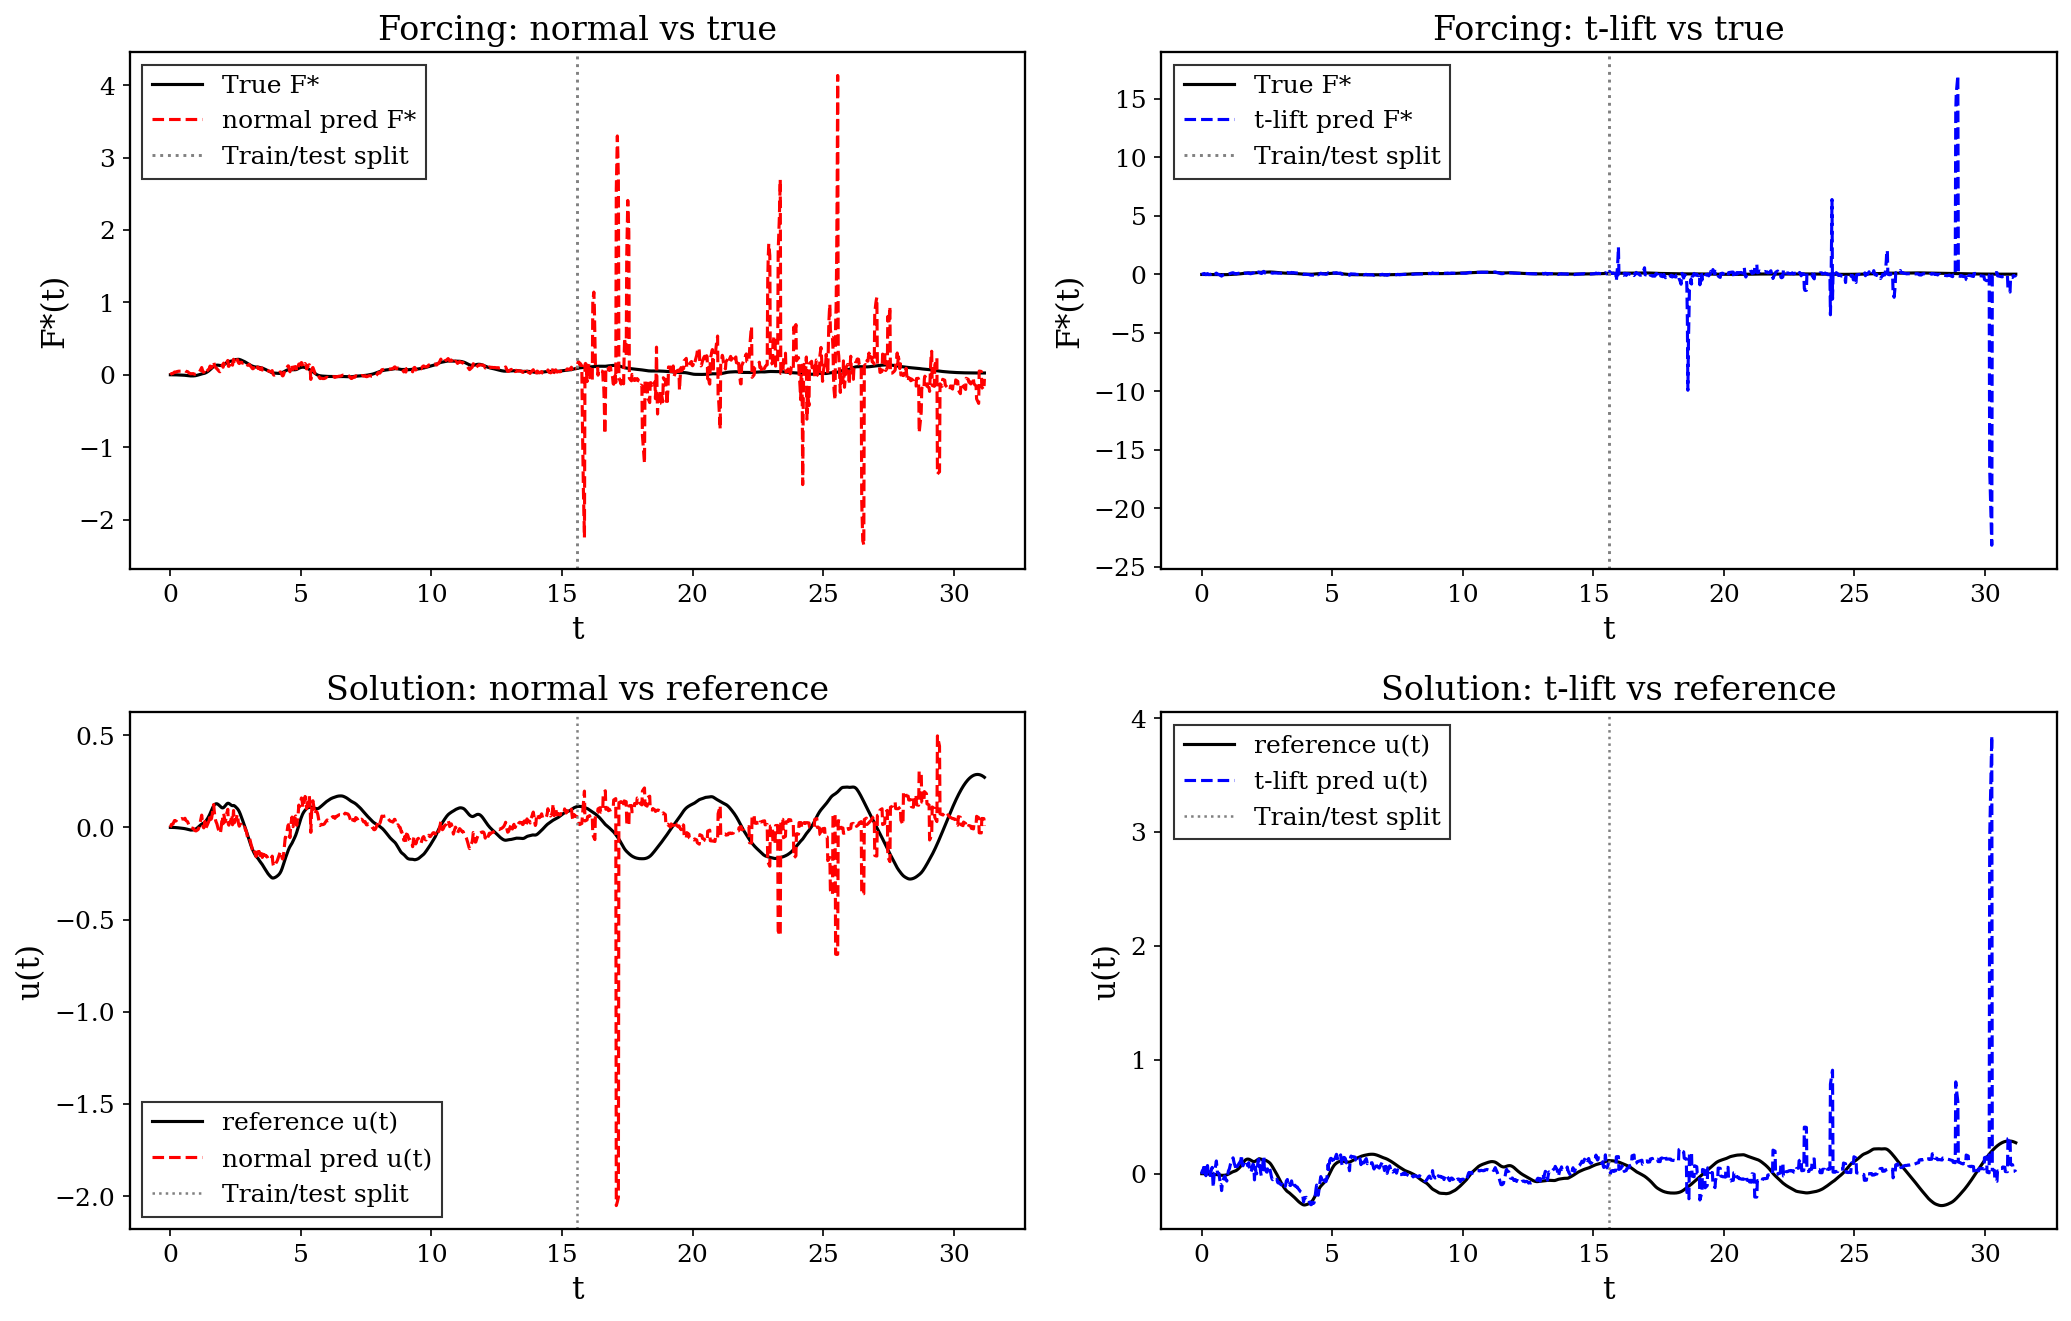


                                   Normal           t-lift  % Improvement
------------------------------------------------------------------------
Training forcing               7.9619e-02       1.5225e-01        -91.22%
Training solution              5.0264e-01       4.0420e-01         19.58%
------------------------------------------------------------------------
Testing forcing                5.7160e+01       9.0734e+02      -1487.36%
Testing solution               3.3412e+00       5.2845e+00        -58.16%
------------------------------------------------------------------------
Train+Test forcing             2.0703e+01       3.2792e+02      -1483.93%
Train+Test solution            2.3716e+00       3.6175e+00        -52.53%


In [ ]:
# 2x2 plots
plot_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full, f_pred_full,
    u_pred_full_tlift, f_pred_full_tlift,
    U_ref, F_star
)

# Relative MSE table
print_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full, f_pred_full,
    u_pred_full_tlift, f_pred_full_tlift,
    U_ref, F_star
)

## Rolling Retrain

In [ ]:
## Rolling Retrain
import time

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_rolling, f_pred_full_rolling = solve_signature_kernel_rolling_retrain(
    t_train=t_train, t_test=t_test,
    f_train=f_train, f_test=f_test,
    k1=m, k2=c, k3=k,
    ua=0.0, upa=0.0,
    depth=sig_depth_rolling, normalize=use_normalization,
    reg=reg_lambda, retrain_every=retrain_iters_rolling,
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for rolling prediction and retrain method: {elapsed:.3f} seconds")

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_tlift_rolling, f_pred_full_tlift_rolling = solve_signature_kernel_rolling_retrain(
    t_train=t_train, t_test=t_test,
    f_train=f_train, f_test=f_test,
    k1=m, k2=c, k3=k,
    ua=0.0, upa=0.0,
    depth=sig_depth_rolling, normalize=use_normalization,
    reg=reg_lambda, retrain_every=retrain_iters_rolling,
    use_tlift=True,
    holder_value=holder_value
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for rolling prediction and retrain method, tlift: {elapsed:.3f} seconds")


GPU SVD | device=cuda:0 | rank=62/780 | rcond=2.220e-16 | cutoff=1.029e-05
GPU SVD | device=cuda:0 | rank=62/785 | rcond=2.220e-16 | cutoff=1.113e-05
GPU SVD | device=cuda:0 | rank=62/790 | rcond=2.220e-16 | cutoff=1.203e-05
GPU SVD | device=cuda:0 | rank=62/795 | rcond=2.220e-16 | cutoff=1.299e-05
GPU SVD | device=cuda:0 | rank=62/800 | rcond=2.220e-16 | cutoff=1.403e-05
GPU SVD | device=cuda:0 | rank=62/805 | rcond=2.220e-16 | cutoff=1.515e-05
GPU SVD | device=cuda:0 | rank=62/810 | rcond=2.220e-16 | cutoff=1.634e-05
GPU SVD | device=cuda:0 | rank=62/815 | rcond=2.220e-16 | cutoff=1.763e-05
GPU SVD | device=cuda:0 | rank=62/820 | rcond=2.220e-16 | cutoff=1.900e-05
GPU SVD | device=cuda:0 | rank=63/825 | rcond=2.220e-16 | cutoff=2.048e-05
GPU SVD | device=cuda:0 | rank=62/830 | rcond=2.220e-16 | cutoff=2.206e-05
GPU SVD | device=cuda:0 | rank=62/835 | rcond=2.220e-16 | cutoff=2.376e-05
GPU SVD | device=cuda:0 | rank=62/840 | rcond=2.220e-16 | cutoff=2.558e-05
GPU SVD | device=cuda:0 |

# Results

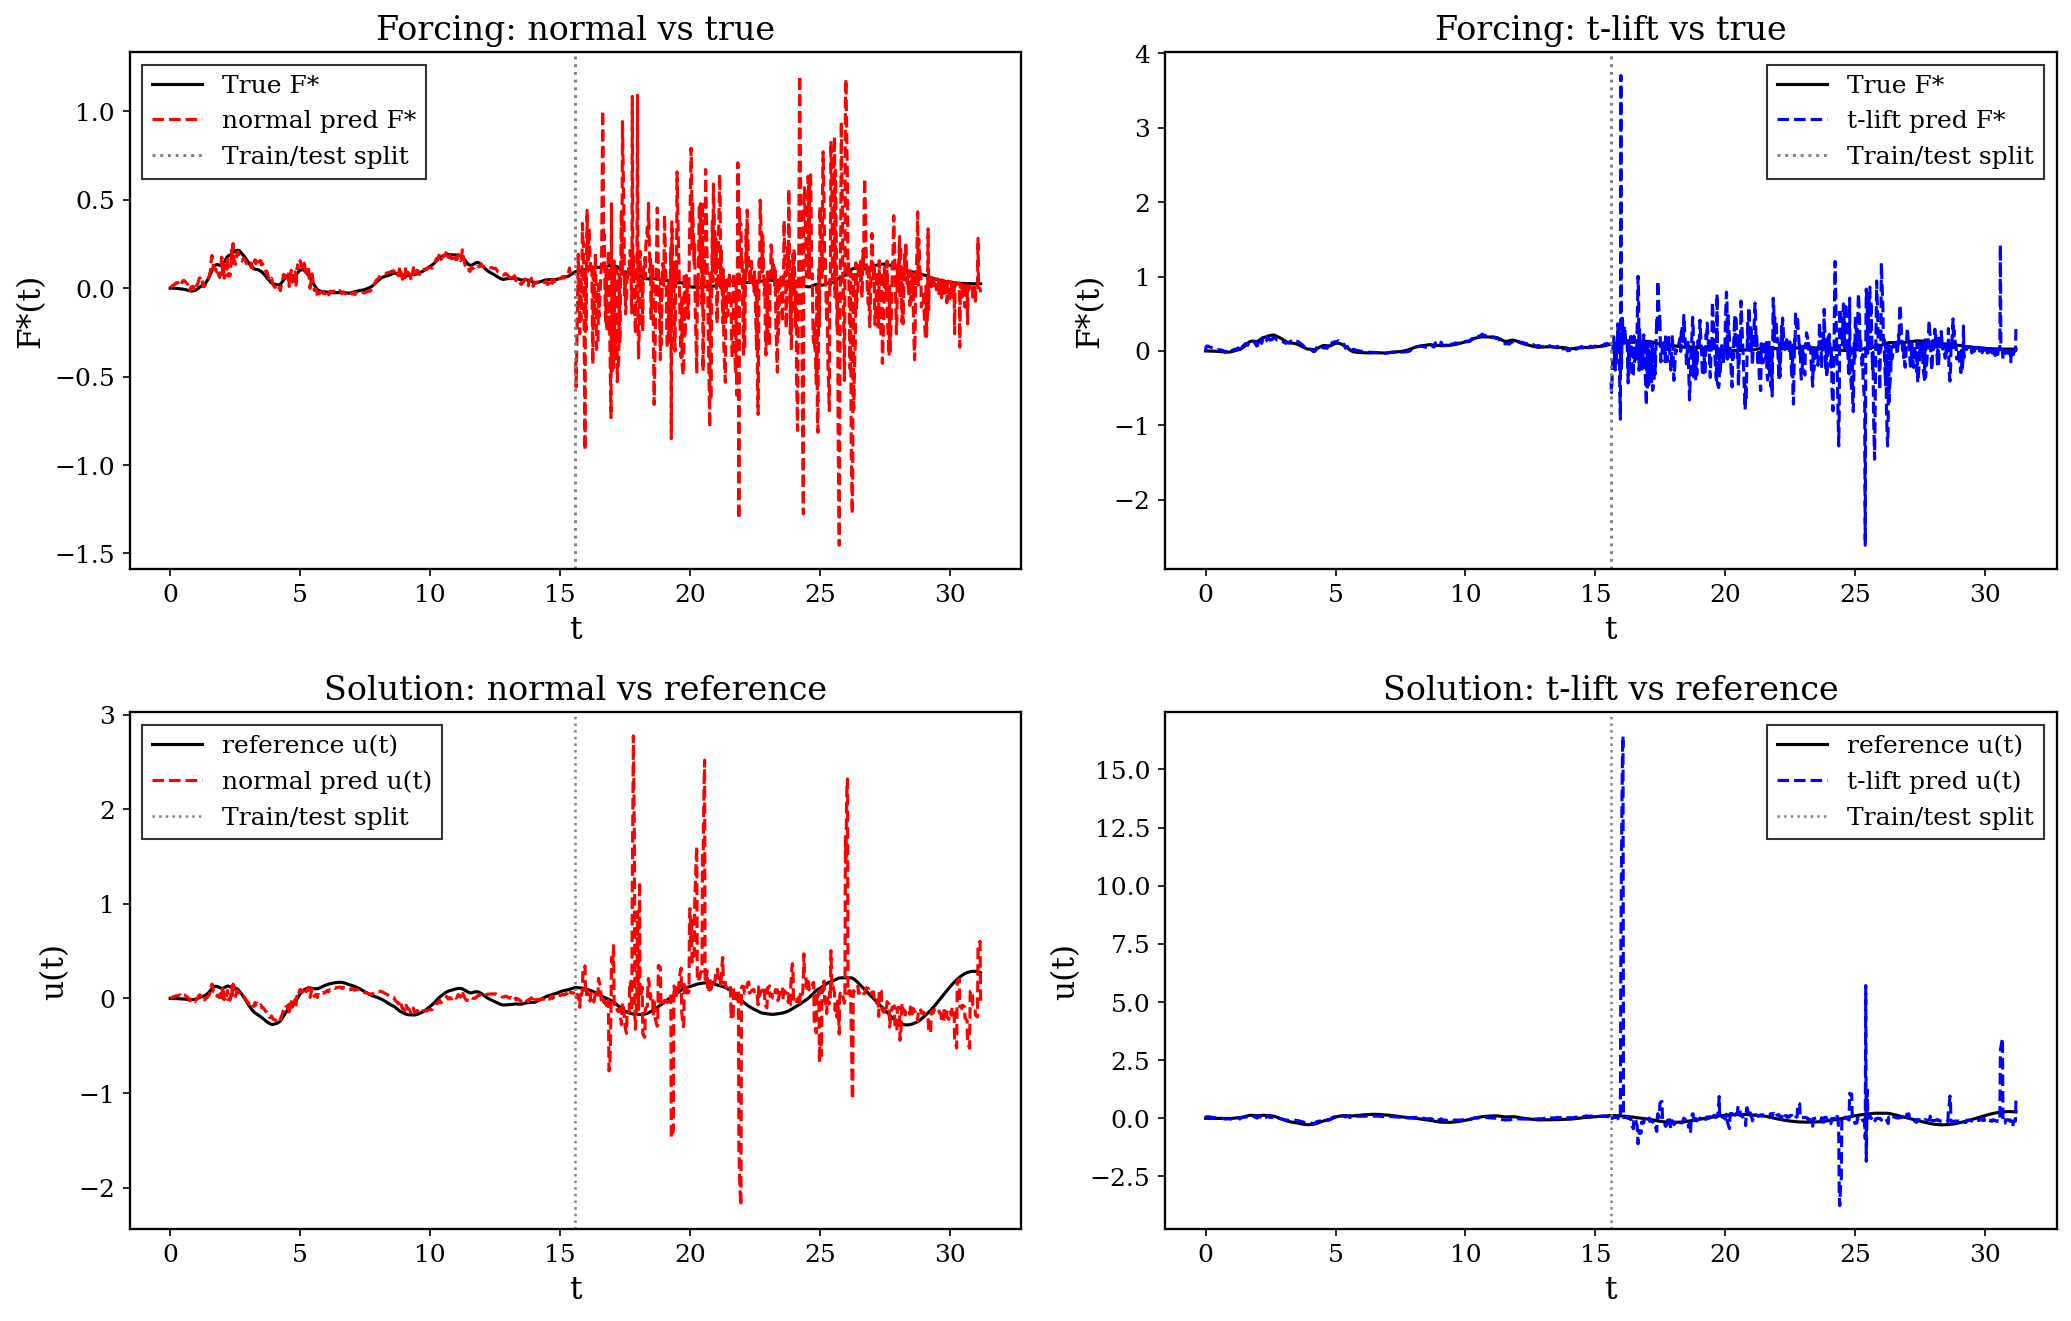


                                   Normal           t-lift  % Improvement
------------------------------------------------------------------------
Training forcing               7.4870e-02       5.2796e-02         29.48%
Training solution              2.7547e-01       3.1263e-01        -13.49%
------------------------------------------------------------------------
Testing forcing                2.2869e+01       2.7341e+01        -19.56%
Testing solution               7.7411e+00       5.8476e+01       -655.40%
------------------------------------------------------------------------
Train+Test forcing             8.3102e+00       9.9120e+00        -19.27%
Train+Test solution            5.1910e+00       3.8609e+01       -643.76%


In [ ]:
plot_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full_rolling, f_pred_full_rolling,
    u_pred_full_tlift_rolling, f_pred_full_tlift_rolling,
    U_ref, F_star
)
print_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full_rolling, f_pred_full_rolling,
    u_pred_full_tlift_rolling, f_pred_full_tlift_rolling,
    U_ref, F_star
)

# Compare

Method                              Split     Forcing Rel MSE   Solution Rel MSE
--------------------------------------------------------------------------------
Predict-Retrain (normal)            Train          7.4870e-02         2.7547e-01
                                    Test           6.9019e+01         2.3549e+00
                                    All            2.4984e+01         1.6446e+00
--------------------------------------------------------------------------------
Predict-Retrain (t-lift)            Train          5.2796e-02         3.1263e-01
                                    Test           5.3997e+02         5.0745e+00
                                    All            1.9512e+02         3.4480e+00
--------------------------------------------------------------------------------
Rolling-Retrain (normal)            Train          7.4870e-02         2.7547e-01
                                    Test           2.2869e+01         7.7411e+00
                            

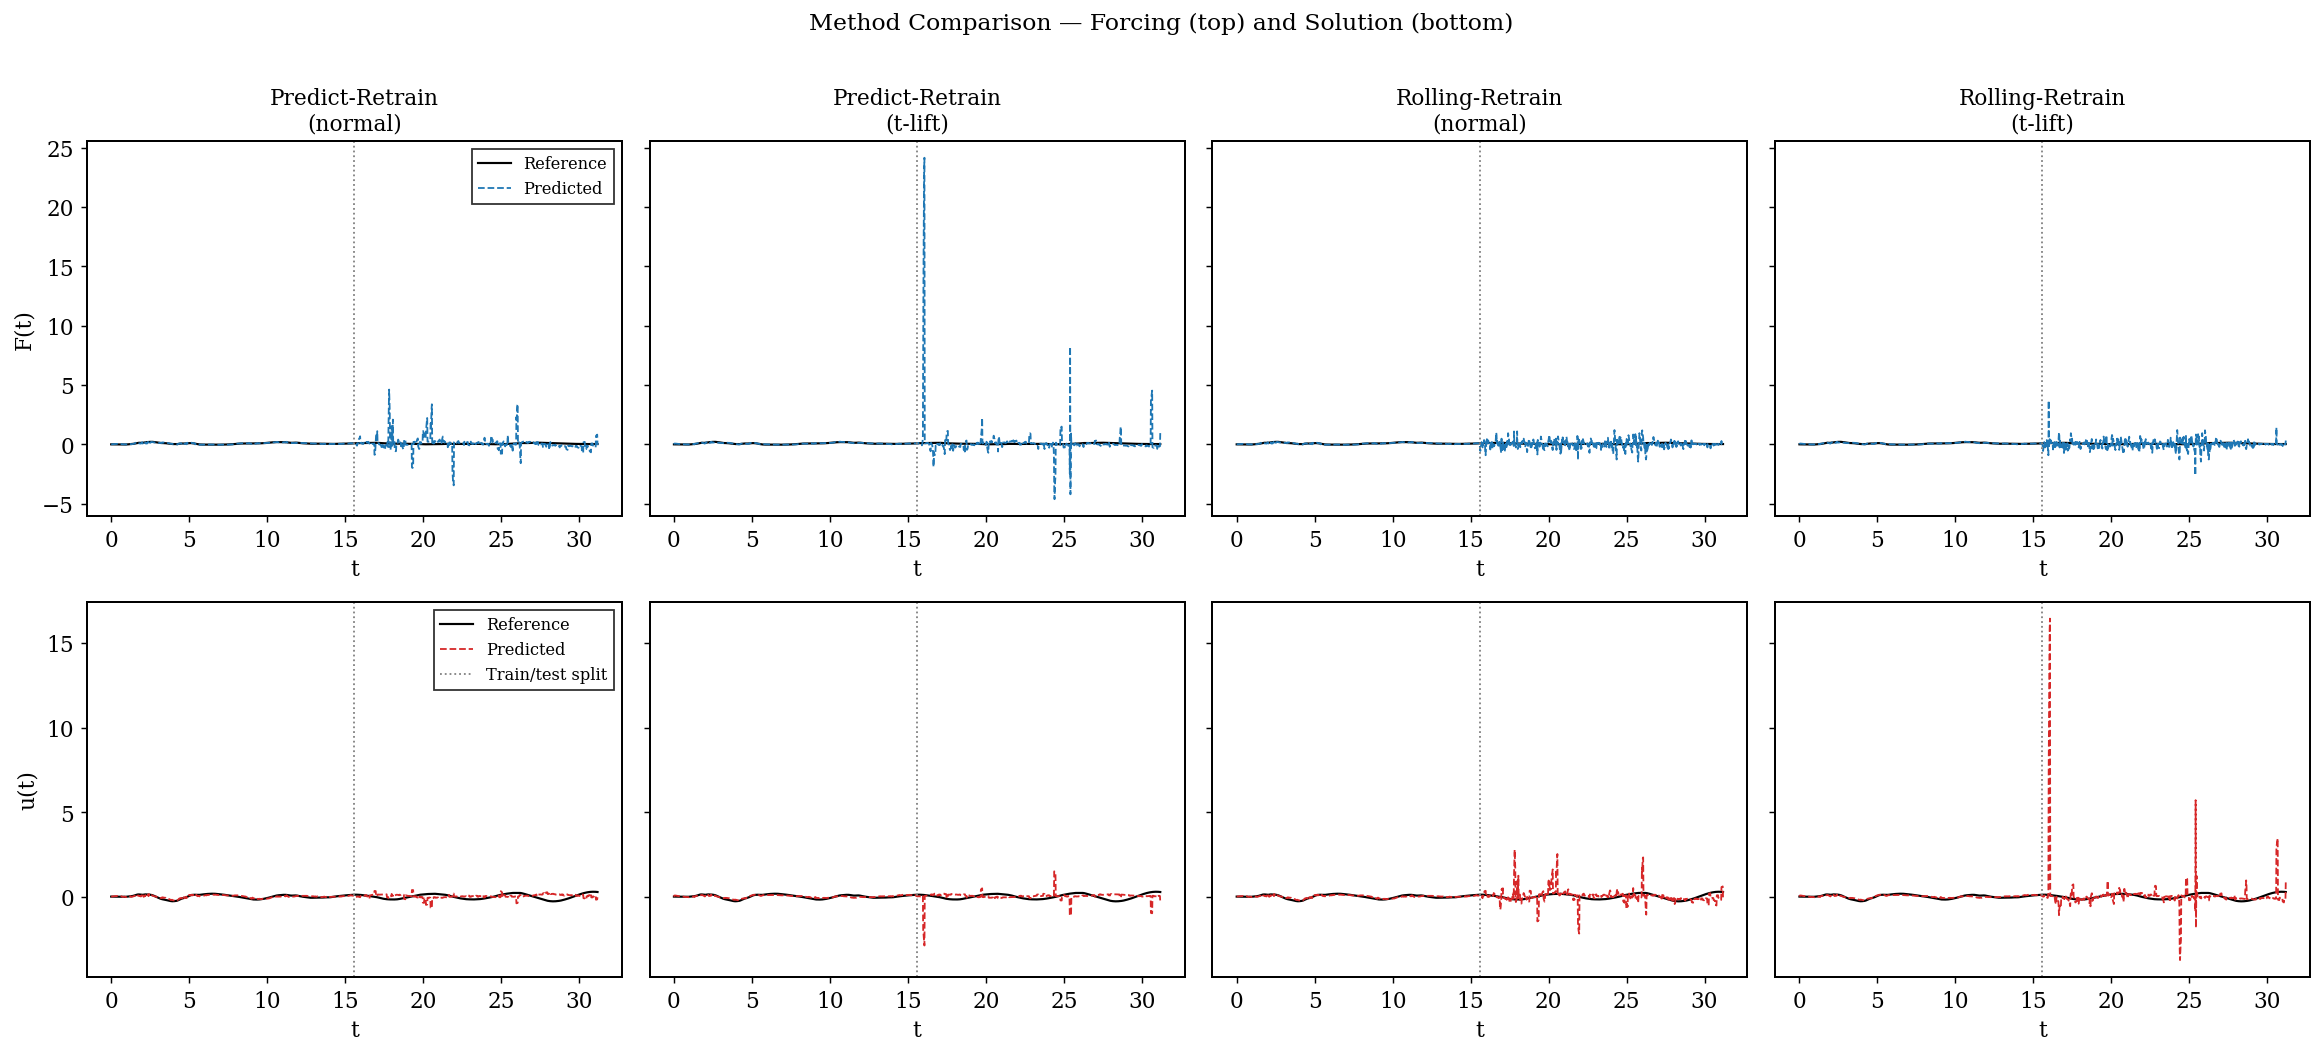

In [ ]:
# --- Call both ---
print_method_comparison(
    t_vals, TRAIN_FRAC,
    f_pred_full, u_pred_full,
    f_pred_full_tlift, u_pred_full_tlift,
    f_pred_full_rolling, u_pred_full_rolling,
    f_pred_full_tlift_rolling, u_pred_full_tlift_rolling,
    F_star, U_ref
)

plot_method_comparison(
    t_vals, TRAIN_FRAC,
    f_pred_full, u_pred_full,
    f_pred_full_tlift, u_pred_full_tlift,
    f_pred_full_rolling, u_pred_full_rolling,
    f_pred_full_tlift_rolling, u_pred_full_tlift_rolling,
    F_star, U_ref
)